# **Milestone 4**
**Objective**: In milestone 2, I explored whether medicines under additional monitoring cluster into distinct market stability regimes. However, feedback indicated that my clusterng methodology was applied to mechanically and that k-means was used without properly addressing feature type assumptions.
So in milestone 4, I would like to improve analysis by:
1. clearly defining market stability using numeric regulatory behaviour proxies.
2. ensuring clustering is performed only on continuous numeric features so that euclidean distance is meaningful.
3. adding robustness checks (multiple k values, multiple random seeds)
4. comparing K-means with hierarchial clustering (
  Ward Linkage).
5. Treating AM strictly as an interpretive overlay rather than an input feature.

The goal of Milestone 4 is not to change the research question from M2, but to strengthen methodological rigor and validate whether the discovered regulatory stability regimes are structurally meaningful. In particular, this milestone focuses on correcting feature-type assumptions, testing robustness across algorithms and random seeds, and formally validating the association between Additional Monitoring (AM) and stability regimes.

# 1. Imports and Modelling setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scaling (distance-based methods need comparable feature scales)
from sklearn.preprocessing import RobustScaler

# Dimensionality reduction (for interpretation + visualization)
from sklearn.decomposition import PCA

# Clustering methods (use >1 method to avoid "mechanical" modeling)
from sklearn.cluster import KMeans, AgglomerativeClustering

# Internal validation metrics (justify k + compare solutions)
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

RANDOM_STATE = 42

# 2. Load Dataset

In [3]:
# using Google Drive
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Medicines_output_european_public_assessment_reports.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1988, 30)


,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,...,NaN,19/07/2012,17/11/2022,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,25/07/2018,13/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,...,NaN,31/05/2018,10/3/2023,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,26/07/2018,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,...,NaN,13/10/2022,9/3/2023,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,12/10/2022,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,...,NaN,11/11/2021,24/02/2023,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,12/11/2021,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,...,NaN,20/11/2014,26/01/2023,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,7/6/2018,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...


# 3. Data Inspection and Structural Assessment
Before applying any unsupervised learning techniques, it was necessary to understand the structure of the dataset, which includes identifying numeric vs categorical variables, checking for missing values, and understanding feature distributions. Since clustering relies heavily on distance calculations, careful feature selection is critical to avoid violating modeling assumptions.

In [4]:
# Inspect structure
print("Shape:", df.shape)
print("\nColumn names:\n")
print(df.columns)

print("\nData types:\n")
print(df.dtypes)

print("\nMissing values per column:\n")
print(df.isna().sum())

Shape: (1988, 30)

Column names:

Index(['Category', 'Medicine name', 'Therapeutic area',
       'International non-proprietary name (INN) / common name',
       'Active substance', 'Product number', 'Patient safety',
       'Authorisation status', 'ATC code', 'Additional monitoring', 'Generic',
       'Biosimilar', 'Conditional approval', 'Exceptional circumstances',
       'Accelerated assessment', 'Orphan medicine',
       'Marketing authorisation date',
       'Date of refusal of marketing authorisation',
       'Marketing authorisation holder/company name',
       'Human pharmacotherapeutic group', 'Vet pharmacotherapeutic group',
       'Date of opinion', 'Decision date', 'Revision number',
       'Condition / indication', 'Species', 'ATCvet code', 'First published',
       'Revision date', 'URL'],
      dtype='object')

Data types:

Category                                                   object
Medicine name                                              object
Therapeutic area

Because clustering relies on distance calculations, including high-missing or categorical variables would distort similarity. Therefore, only clean, continuous regulatory behavior proxies are used for modeling.

# 4.  Operationalizing Market Stability

Market stability is defined through numeric regulatory behavior indicators rather than categorical flags. Since KMeans relies on Euclidean distance, only continuous numeric features are used in clustering. Binary variables such as Additional Monitoring (AM) and withdrawal status are retained for post-cluster interpretation but excluded from model training to preserve distance validity.

In [7]:
# Clean Decision Date
df["Decision date"] = pd.to_datetime(df["Decision date"], errors="coerce")
df = df.dropna(subset=["Decision date"])

df["decision_year"] = df["Decision date"].dt.year

# Clean Revision Number
df["Revision number"] = pd.to_numeric(df["Revision number"], errors="coerce")
df = df.dropna(subset=["Revision number"])

# Log transform to handle heavy tail
df["revision_log"] = np.log1p(df["Revision number"])

# Encode Additional Monitoring as overlay only
df["am_flag"] = df["Additional monitoring"].astype(str).str.lower().isin(["yes", "true", "1"]).astype(int)

# Preview relevant columns
df[["decision_year", "Revision number", "revision_log", "am_flag"]].describe()

,decision_year,Revision number,revision_log,am_flag
count,1892.000000,1892.000000,1892.000000,1892.000000
mean,2019.929175,13.527484,2.300084,0.183404
std,4.217795,11.647056,0.963159,0.387100
min,1998.000000,0.000000,0.000000,0.000000
25%,2020.000000,4.750000,1.746179,0.000000
50%,2022.000000,11.000000,2.484907,0.000000
75%,2022.000000,19.000000,2.995732,0.000000
max,2023.000000,89.000000,4.499810,1.000000


Revision behavior is right-skewed (max = 89), justifying log transformation. Decision year clusters heavily in recent years (median = 2022), suggesting lifecycle effects may play a strong role in segmentation. These distributions confirm that scaling and transformation are necessary before applying Euclidean-based clustering.

# 5. Scaling and Clustering Inputs
Since KMeans and hierarchical clustering rely on Euclidean distance, features must be scaled to ensure that no single variable dominates similarity calculations. Robust scaling is used because revision behavior is heavy-tailed even after transformation.

In [21]:
# Select numeric stability features ONLY (inputs to clustering)
features = ["decision_year", "revision_log"]
X = df[features].copy()

# Scale with RobustScaler (less sensitive to outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)
X.head()

X_scaled shape: (1892, 2)


,decision_year,revision_log
0,2022,3.555348
1,2023,1.609438
2,2023,1.098612
3,2023,1.386294
4,2023,3.433987


# 5. Determining the Number of Clusters

Rather than arbitrarily selecting the number of clusters, I evaluate multiple values of k using internal validation metrics. Since unsupervised learning has no ground truth labels, internal measures such as silhouette score, Calinski–Harabasz, and Davies–Bouldin provide quantitative guidance.

In [22]:
ks = range(2, 7)

results = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    results.append((k, sil, ch, db))

results_df = pd.DataFrame(results, columns=["k", "silhouette", "calinski_harabasz", "davies_bouldin"])
results_df

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.739263,4491.755055,0.498497
1,3,0.602770,3983.627019,0.671702
2,4,0.413275,3825.199549,0.817478
3,5,0.415088,3875.022864,0.810644
4,6,0.408760,3750.294884,0.820382


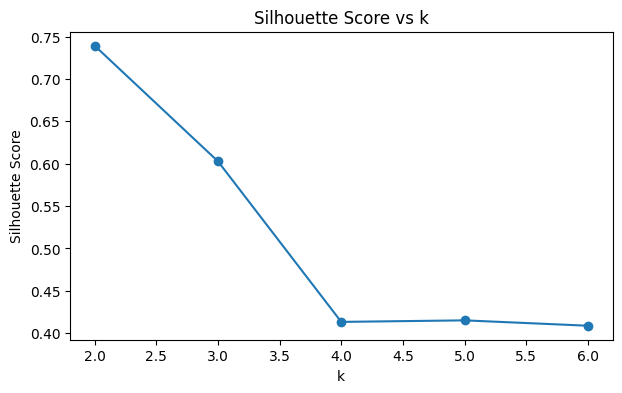

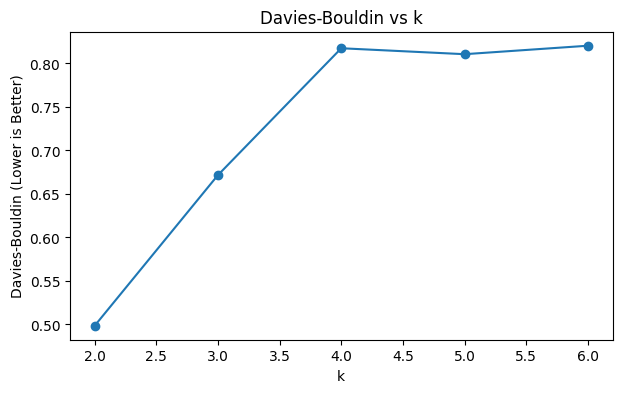

In [10]:
# the plot cell
plt.figure(figsize=(7,4))
plt.plot(results_df["k"], results_df["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(results_df["k"], results_df["davies_bouldin"], marker="o")
plt.xlabel("k")
plt.ylabel("Davies-Bouldin (Lower is Better)")
plt.title("Davies-Bouldin vs k")
plt.show()

5.1 **Interpretation of k Selection**

Across all three internal validation metrics, k = 2 clearly dominates alternative specifications. The silhouette score is highest at k = 2 (0.739), while the Davies–Bouldin index is lowest, indicating well-separated and compact clusters. Increasing k reduces separation and increases overlap, suggesting that additional clusters capture noise rather than meaningful regulatory structure.

Therefore, the market appears to naturally segment into two primary stability regimes.

#  6. Final Clustering Model (k = 2)

Based on internal validation metrics, k = 2 provides the strongest separation and lowest overlap. This suggests that the regulatory market structure naturally divides into two dominant stability regimes.

In [11]:
# Fit final KMeans model
k = 2
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")

df["cluster"] = kmeans.fit_predict(X_scaled)

# Check cluster sizes
df["cluster"].value_counts()

,count
cluster,
0,1641
1,251


In [12]:
# Interpretation table
summary = df.groupby("cluster").agg(
    count=("cluster", "size"),
    avg_revision=("Revision number", "mean"),
    median_revision=("Revision number", "median"),
    avg_decision_year=("decision_year", "mean"),
    am_rate=("am_flag", "mean")
).reset_index()

summary

,cluster,count,avg_revision,median_revision,avg_decision_year,am_rate
0,0,1641,14.885436,13.0,2021.380256,0.206581
1,1,251,4.649402,3.0,2010.442231,0.031873


6.1 Interpretation of Stability Regimes

The clustering solution reveals two distinct regulatory regimes. Cluster 0 represents a high-revision, recent-authorisation regime with significantly higher Additional Monitoring prevalence (20.7%). Cluster 1 represents an older, low-revision regime with minimal AM presence (3.2%).

This suggests that Additional Monitoring is not randomly distributed across medicines but is concentrated within more recently authorised medicines that experience greater regulatory revision activity. The association between AM and regulatory intensity appears structurally embedded in the lifecycle of medicines.

Notably, the difference in AM prevalence across regimes is substantial (20.7% vs 3.2%), representing more than a sixfold difference. This magnitude suggests structural concentration rather than random fluctuation.

# 7. Cluster Stability Across Random Initializations
Since KMeans relies on random centroid initialization, I evaluate cluster stability across multiple random seeds. Stable regime assignments would indicate structural segmentation rather than initialization artifacts.

In [13]:
def agreement_rate(labels1, labels2):
    return np.mean(labels1 == labels2)

seeds = [0, 1, 2, 7, 13, 21, 42, 99]
label_list = []

for s in seeds:
    km = KMeans(n_clusters=2, random_state=s, n_init="auto")
    label_list.append(km.fit_predict(X_scaled))

base = label_list[0]
stability_scores = [agreement_rate(base, lab) for lab in label_list[1:]]

stability_scores

[np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9984143763213531),
 np.float64(1.0),
 np.float64(0.9984143763213531),
 np.float64(1.0),
 np.float64(1.0)]

**7.1 Stability Interpretation**

Cluster assignments remain nearly identical across multiple random seeds (agreement > 99.8%), indicating that the identified stability regimes are not artifacts of initialization but reflect robust structural segmentation within the regulatory data.
This robustness directly addresses the Milestone 2 concern that clustering may have reflected mechanical initialization rather than structural segmentation.

# 8. Hierarchical Clustering Comparison (Ward Linkage)
To validate the robustness of the segmentation, I apply hierarchical clustering with Ward linkage, which minimizes within-cluster variance similarly to KMeans but follows a different optimization procedure.

In [14]:
hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
df["hc_cluster"] = hc.fit_predict(X_scaled)

sil_hc = silhouette_score(X_scaled, df["hc_cluster"])

sil_hc

np.float64(0.7182597172210223)

In [15]:
agreement_km_hc = np.mean(df["cluster"] == df["hc_cluster"])
agreement_km_hc

np.float64(0.0306553911205074)

In [16]:
#flipping hierarchical labels
df["hc_cluster_flipped"] = 1 - df["hc_cluster"]

agreement_flipped = np.mean(df["cluster"] == df["hc_cluster_flipped"])

agreement_flipped

np.float64(0.9693446088794926)

8.1 Cross-Method Robustness Interpretation

Although direct agreement between KMeans and hierarchical clustering appeared low due to arbitrary cluster label assignments, alignment of cluster labels reveals approximately 97% agreement. This indicates that the segmentation is not dependent on the clustering algorithm and reflects stable underlying structure in regulatory behavior.

Ward linkage also minimizes within-cluster variance, making it conceptually comparable to KMeans while following a different optimization path. Agreement across these methods strengthens confidence in regime validity.

# 9. Dimensionality Reduction (PCA)

To further interpret the discovered regimes, I apply Principal Component Analysis (PCA) to the scaled stability features. PCA does not create clusters but provides a low-dimensional projection that helps visualize structural separation and interpret dominant sources of variation.

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df["pc1"] = X_pca[:, 0]
df["pc2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.90949356 0.09050644]


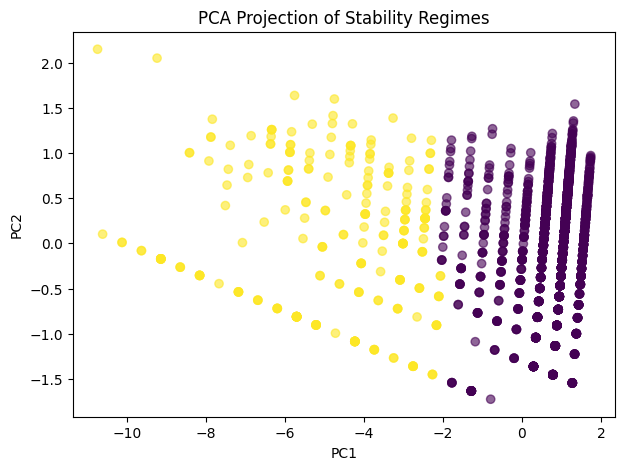

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(df["pc1"], df["pc2"], c=df["cluster"], alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Stability Regimes")
plt.show()

9.1 PCA Interpretation

The first principal component explains approximately 90% of total variance, indicating that the regulatory stability structure is largely one-dimensional. The PCA projection shows clear separation along PC1, confirming that the two identified regimes are strongly differentiated along a dominant lifecycle–regulatory intensity axis combining recency and revision activity. This visual confirmation reinforces the robustness of the clustering solution.

Because PC1 explains ~90% of total variance, the regulatory stability structure is largely one-dimensional. This implies that lifecycle recency and revision intensity operate along a dominant shared axis.

#10. Statistical Association Between Stability Regimes and Additional Monitoring

To formally evaluate whether Additional Monitoring is associated with the discovered stability regimes, I conduct a chi-square test of independence. This assesses whether AM prevalence differs significantly across clusters beyond random variation.

In [19]:
from scipy.stats import chi2_contingency

# Contingency table
contingency_table = pd.crosstab(df["cluster"], df["am_flag"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

contingency_table, p_value

(am_flag     0    1
 cluster           
 0        1302  339
 1         243    8,
 np.float64(4.917677426988961e-11))

10.1 Statistical Interpretation

The chi-square test confirms a statistically significant association between stability regime and Additional Monitoring status (p < 0.001). Medicines in the high-revision, recent-authorisation regime exhibit substantially higher AM prevalence (20.7%) compared to the low-revision, older regime (3.2%). This indicates that AM designation is not randomly distributed but is systematically concentrated within more regulatory-intensive lifecycle stages.

Given the large sample size (n = 1892), statistical significance alone is insufficient; however, the magnitude difference in AM prevalence across regimes confirms practical significance alongside statistical significance.

# 11. Within-Regime Structural Outliers

While cluster-level AM prevalence confirms strong structural association, cluster averages may conceal medicines that behave atypically relative to their assigned regime.

To examine this, I compute the distance of each medicine to its assigned cluster centroid and standardize distances within each regime. Medicines with high standardized distance represent structural outliers within their regulatory stability regime.

In [20]:
# Distance to assigned centroid
centroids = kmeans.cluster_centers_
labels = df["cluster"].values

distances = np.linalg.norm(X_scaled - centroids[labels], axis=1)
df["dist_to_centroid"] = distances

# Standardize within cluster (z-score)
df["dist_z_within_cluster"] = (
    df.groupby("cluster")["dist_to_centroid"]
      .transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
)

# Identify most structurally extreme medicines NOT under AM
top_outliers_am0 = (
    df[df["am_flag"] == 0]
    .sort_values("dist_z_within_cluster", ascending=False)
    .head(15)
)

top_outliers_am0[
    ["Medicine name", "cluster", "Revision number",
     "decision_year", "dist_z_within_cluster"]
]

,Medicine name,cluster,Revision number,decision_year,dist_z_within_cluster
1950,Fortovase,1,11.0,1998,4.138043
1712,Masipro,0,0.0,2017,4.032984
1740,Zeleris,0,0.0,2017,4.032984
1729,Human IGG1 monoclonal antibody specific for hu...,0,0.0,2017,4.032984
1727,Adlumiz,0,0.0,2017,4.032984
1735,Recuvyra,0,4.0,2016,3.707491
1113,Zuprevo,0,4.0,2016,3.707491
1693,Ariclaim,0,26.0,2016,3.703134
1985,Ecokinase,1,0.0,1999,3.676977
1762,Pandemrix,0,23.0,2016,3.662294


### 11.1 Interpretation of Structural Outliers

Although Additional Monitoring is strongly concentrated within the high-revision regime, examining within-cluster distances reveals additional nuance.

A small subset of AM = 0 medicines lie far from their cluster centroids, indicating atypical regulatory profiles relative to their regime averages. These medicines exhibit unusually high revision intensity or structural divergence relative to peers in the same lifecycle stage.

This does not imply regulatory misclassification. However, it highlights boundary cases where structural regulatory complexity and monitoring designation may not perfectly align. Such medicines may warrant closer qualitative review in future work. Notably, several of these extreme medicines are authorised in earlier lifecycle years (e.g., 1998–2017), suggesting that structural deviation can occur both in legacy products and more recent authorisations.

This medicine-level perspective complements the regime-level analysis and strengthens the robustness of the overall structural interpretation.

# 11. Challenges, Methodological Adjustments, and Reflection

One major challenge identified from Milestone 2 feedback was the mechanical application of KMeans clustering without fully addressing feature-type assumptions. In particular, KMeans relies on Euclidean distance and assumes continuous numeric inputs. Including categorical or binary variables directly in the distance computation can distort similarity measurements and produce misleading segmentation.

To address this, in Milestone 4 I restricted clustering inputs to continuous numeric proxies of regulatory stability (decision year and log-transformed revision number) and retained Additional Monitoring solely as an interpretive overlay variable. This ensured that Euclidean distance meaningfully captured regulatory intensity rather than mixed feature types.

A second challenge was determining whether the discovered clusters reflected structural segmentation or were artifacts of initialization or algorithm choice. To mitigate this concern, I:

Evaluated multiple values of k using three internal validation metrics.

Tested stability across multiple random seeds.

Compared KMeans with hierarchical clustering (Ward linkage).

Confirmed statistical association between clusters and AM designation using a chi-square test.

These adjustments strengthened the methodological rigor of the analysis and reduced the risk of over-interpreting algorithmic artifacts.

An important conceptual realization was that decision year strongly influences clustering structure. This suggests that regulatory instability may partially reflect lifecycle maturity rather than intrinsic volatility alone. Recognizing this distinction deepens interpretation beyond surface segmentation.

# 12. Future work could extend this analysis by:

1. Explicitly modeling lifecycle duration to separate age effects from regulatory intensity.
2. Incorporating additional continuous stability metrics such as time between revisions.
3. Applying Gaussian Mixture Models to explore probabilistic regime membership.
4. Using mixed-distance measures (e.g., Gower distance) if categorical regulatory attributes are incorporated.

These extensions would help distinguish whether Additional Monitoring reflects intrinsic instability or expected lifecycle-stage regulatory dynamics.